In [11]:
%pip install torch

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
import numpy as np
import sys
import pandas as pd
import torch.cuda
from openpyxl import load_workbook, Workbook

notebook_dir = os.path.abspath('')

root_dir = os.path.abspath(os.path.join(notebook_dir, '..', '..'))

if root_dir not in sys.path:
    sys.path.append(root_dir)

from stable_baselines3 import SAC, PPO
from aml_project.environments.lettuce_greenhouse import LettuceGreenhouse
from aml_project.common.plot_gh_variables import create_trajectory_figure, plot_trajectory

# Define the exact coefficients from Morcego et al. (2023)
# reward_coefs = [c_r1 (growth), c_r_co2_2 (CO2 in-bounds)]
custom_reward_coefs = np.array([16.0, 0.0005])

# penalty_coefs = [c_r_u1 (CO2), c_r_u2 (Vent), c_r_u3 (Heat), c_r_co2_1 (CO2 bounds), c_r_T1 (Temp low), c_r_T2 (Temp high)]
custom_penalty_coefs = np.array([4.5360e-4, 0.0075, 8.5725e-4, 0.1, 0.001, 0.0005])

weather_file = root_dir + r'\aml_project\environments\weather\outdoorWeatherWurGlas2014.mat'

env = LettuceGreenhouse(
    weather_data_dir=weather_file, 
    reward_coefs=custom_reward_coefs, 
    penalty_coefs=custom_penalty_coefs
)



Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:

# Initialize the PPO model
device = "cuda" if torch.cuda.is_available() else "cpu"
model = PPO("MlpPolicy", env, verbose=1, learning_rate=1e-3, batch_size=64, device=device)
model.learn(total_timesteps=1000) 
model.save("ppo_lettuce_greenhouse")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 192       |
|    ep_rew_mean     | -1.23e+07 |
| time/              |           |
|    fps             | 839       |
|    iterations      | 1         |
|    time_elapsed    | 2         |
|    total_timesteps | 2048      |
----------------------------------


In [3]:
# We must reset the environment before testing
from aml_project.common.helper_functions import weather2ppmrh


obs, info = env.reset()

done = False
truncated = False

# Initialize arrays to store measurements, actions, and rewards
y = np.zeros((env.N+1, env.ny))
u = np.zeros((env.N, env.action_space.shape[0]))
rewards = np.zeros((env.N, 1))

# Set initial state and action
y[0] = env.g()
env.prev_action = np.zeros(env.action_space.shape[0])

# Initialize loop variables
k = 0
terminated = False
done = False

# Generate trajectory until termination
while not terminated and not done:
    # Predict the action using the trained model
    action, _states = model.predict(obs, deterministic=True)
    # Take the action in the environment
    obs, reward, done, truncated, info = env.step(action)

    # Store the previous action
    u[k] = env.prev_action

    # Store the observation as a measurement
    y[k+1] = obs[:env.ny]

    # Accumulate the reward
    rewards[k] += reward

    # Increment the step counter
    k += 1

# Return the generated trajectory
y = y[:env.N]
d = weather2ppmrh(env.d[:env.N])
u = u[:env.N]
r = rewards[:env.N]


Plotting results...


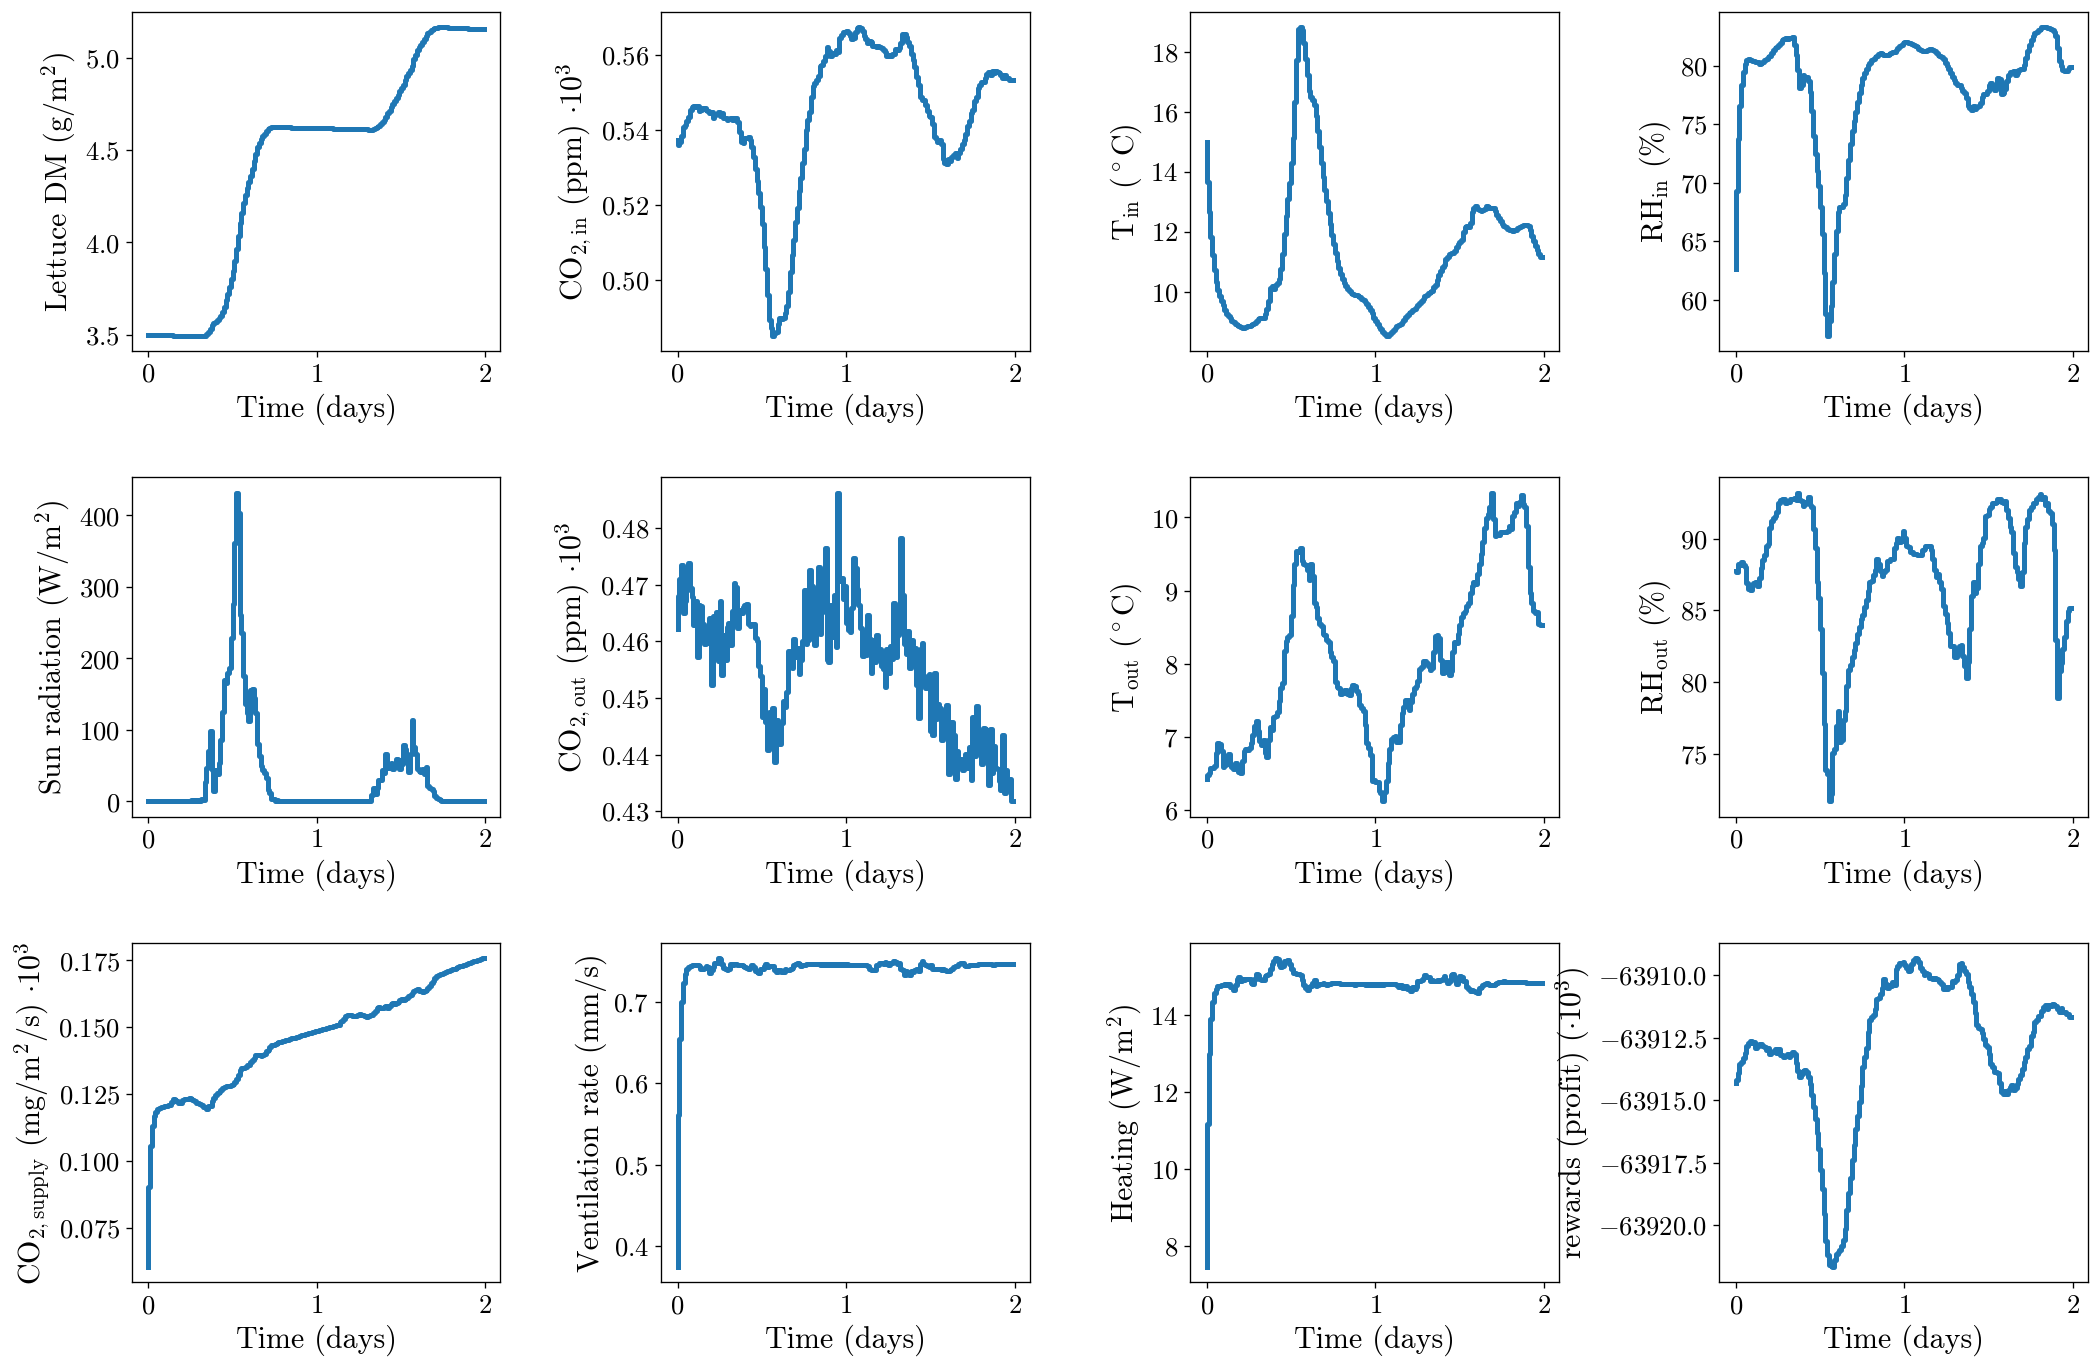

In [ ]:
print("Plotting results...")

nvars = 12
# plot the resulting trajectory
n_per_day = int(24*3600/env.h) # control frequency per day
label= 'Trained PPO policy'
trajectory = np.concatenate((y, d, u, r), axis=1)
fig, axes = create_trajectory_figure(nvars, env.L, env.h, env.c, None, None)
fig, axes = plot_trajectory(fig, axes, trajectory, env.L, env.h, env.c, 0, env.n_days, n_per_day, label)

In [5]:
def run_zero_input_baseline(env):
    # First heuristic where we hold all inputs at 0 (minimum)
    obs, info = env.reset()
    terminated = False
    done = False
    
    # Action space is scaled between -1 and 1. -1 corresponds to 0 physical input.
    zero_action = np.array([-1.0, -1.0, -1.0], dtype=np.float32) 
    
    while not terminated and not done:
        obs, reward, terminated, truncated, info = env.step(zero_action)
        
    return info['profit'].sum(), info


def run_heuristic_baseline(env):
    # Second heuristic where we dose CO2 if below 850 ppm, heat if below 16C, and ventilate if above 19.5C
    obs, info = env.reset()
    terminated = False
    done = False
    
    while not terminated and not done:
        # obs[:4] corresponds to greenhouse measurements: [dry_weight, co2_ppm, temp_c, rh]
        co2_ppm = obs[1]
        temp_c = obs[2]
        
        # CO2 Dosing 
        co2_act = 0.2 if co2_ppm < 850 else -1.0
        
       # Temperature 
        if temp_c < 16.0:
            heat_act = 0.5  # Turn on heating
            vent_act = -1.0 # Close vents to trap heat
        elif temp_c > 19.5:
            heat_act = -1.0 # Turn off heating
            vent_act = 0.3  # Open vents to cool down
        else:
            heat_act = -1.0 # Optimal band: do nothing
            vent_act = -1.0
            
        action = np.array([co2_act, vent_act, heat_act], dtype=np.float32)
        obs, reward, terminated, truncated, info = env.step(action)
        
    return info['profit'].sum(), info

In [ ]:
# Actual evaluation of the trained SAC agent
sac_total_profit = info['profit'].sum()

zero_profit, zero_info = run_zero_input_baseline(env)
heuristic_profit, heuristic_info = run_heuristic_baseline(env)

print(f"--- Cumulative Profit Comparison ---")
print(f"Zero-Input Baseline Profit : {zero_profit:.2f}")
print(f"Heuristic Baseline Profit  : {heuristic_profit:.2f}")
print(f"Trained Agent Profit   : {sac_total_profit:.2f}")

--- Cumulative Profit Comparison ---
Zero-Input Baseline Profit : 23.35
Heuristic Baseline Profit  : 29.48
Trained SAC Agent Profit   : 24.01
